### 5. Faltan deltas en mapas (fraction of wet days, mean over all days, mean over wet days)

# Mapas de delta en precipitación (CR2MET)

Cambios espaciales entre **1979–2000** (P₁) y **2001–2021** (P₂), alineado con `pregunta5.ipynb`.

Métricas (mismas definiciones que `pruea.ipynb`, wet day `pr ≥ 1 mm/día`):

1. **Fracción de wet days** (%)
2. **Precipitación media sobre todos los días** (mm/día)
3. **Precipitación media solo en wet days** (mm/día lluvioso)

Para cada métrica se grafica **Δ = P₂ − P₁** sobre Chile continental (máscara Natural Earth).

Ambos periodos tienen **21 años** (opción B: se excluye 1979 del periodo antiguo).

In [4]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

plt.rcParams['figure.figsize'] = (11, 8)

# =====================================================================
# CONFIGURACION
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2021-12-31'
PERIOD_1 = ('1980-01-01', '2000-12-31')
PERIOD_2 = ('2001-01-01', '2021-12-31')
WET_THRESHOLD = 1.0  # mm/dia
CHILE_EXTENT = [-76, -65, -56, -17]

PR_GLOB = './pr/CR2MET_pr_v2.5_day_*.nc'


def load_chile_geometry():
    reader = shpreader.Reader(
        shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
    )
    geoms = [
        rec.geometry
        for rec in reader.records()
        if rec.attributes.get('NAME') == 'Chile' or rec.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_latlon(lat1d, lon1d, geometry):
    lat2d, lon2d = np.meshgrid(lat1d, lon1d, indexing='ij')
    prepared = prep(geometry)
    mask = np.fromiter(
        (
            prepared.contains(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            or geometry.touches(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            for j in range(lat2d.shape[0])
            for i in range(lat2d.shape[1])
        ),
        dtype=bool,
        count=lat2d.size,
    ).reshape(lat2d.shape)
    return xr.DataArray(mask, coords={'lat': lat1d, 'lon': lon1d}, dims=('lat', 'lon'), name='chile_mask')


def wet_day_fraction(pr, threshold=WET_THRESHOLD):
    return (pr >= threshold).mean(dim='time') * 100.0


def mean_precip_all_days(pr):
    return pr.mean(dim='time')


def mean_precip_wet_days(pr, threshold=WET_THRESHOLD):
    return pr.where(pr >= threshold).mean(dim='time', skipna=True)


def compute_metric_fields(pr_period, threshold=WET_THRESHOLD):
    return {
        'wet_fraction_pct': wet_day_fraction(pr_period, threshold),
        'mean_all_mm_day': mean_precip_all_days(pr_period),
        'mean_wet_mm_day': mean_precip_wet_days(pr_period, threshold),
    }


def summarize_delta(field_delta, mask_da, metric_label, units):
    vals = field_delta.where(mask_da).values.ravel()
    vals = vals[np.isfinite(vals)]
    return {
        'Metrica': metric_label,
        'Unidades delta': units,
        'Pixeles validos': int(vals.size),
        'Delta medio espacial': float(np.mean(vals)),
        'Delta mediano espacial': float(np.median(vals)),
        'Fraccion pixeles delta > 0': float(np.mean(vals > 0)),
    }


def symmetric_limits(data, mask_da, q=98):
    vals = data.where(mask_da).values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 1.0
    lim = float(np.nanpercentile(np.abs(vals), q))
    return max(lim, 1e-6)


def plot_delta_map(delta_da, mask_da, *, title, cbar_label, cmap='RdBu', vmax=None):
    if vmax is None:
        vmax = symmetric_limits(delta_da, mask_da)

    plot_da = delta_da.where(mask_da)
    fig = plt.figure(figsize=(9, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)
    ax.set_extent(CHILE_EXTENT)

    im = plot_da.plot.pcolormesh(
        ax=ax,
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        add_colorbar=False,
    )
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.03)
    cbar.set_label(cbar_label)
    ax.set_title(title, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
    return vmax


print('1/3: Cargando CR2MET y construyendo mascara de Chile...')
if not list(Path('.').glob('pr/CR2MET_pr_v2.5_day_*.nc')):
    raise FileNotFoundError('No se encontraron archivos CR2MET en ./pr/')

ds = xr.open_mfdataset(
    PR_GLOB,
    combine='by_coords',
    engine='netcdf4',
    chunks={'time': 365},
)
pr = ds['pr'].sel(time=slice(START_DATE, END_DATE))

chile_geom = load_chile_geometry()
chile_mask = build_chile_mask_latlon(pr['lat'].values, pr['lon'].values, chile_geom)

pr_p1 = pr.sel(time=slice(*PERIOD_1))
pr_p2 = pr.sel(time=slice(*PERIOD_2))

print(f'Periodo total: {START_DATE} a {END_DATE}')
print(f'P1: {PERIOD_1[0]} a {PERIOD_1[1]} | P2: {PERIOD_2[0]} a {PERIOD_2[1]}')
print(f'Wet day: pr >= {WET_THRESHOLD} mm/dia')
print(f'Pixeles Chile en CR2MET: {int(chile_mask.sum().values)}')

1/3: Cargando CR2MET y construyendo mascara de Chile...
Periodo total: 1980-01-01 a 2021-12-31
P1: 1980-01-01 a 2000-12-31 | P2: 2001-01-01 a 2021-12-31
Wet day: pr >= 1.0 mm/dia
Pixeles Chile en CR2MET: 30682


In [5]:
# =====================================================================
# CALCULO DE CAMPOS Y DELTAS
# =====================================================================
print('2/3: Calculando metricas por periodo (puede tardar unos minutos)...')

fields_p1 = {k: v.compute() for k, v in compute_metric_fields(pr_p1).items()}
fields_p2 = {k: v.compute() for k, v in compute_metric_fields(pr_p2).items()}

deltas = {key: fields_p2[key] - fields_p1[key] for key in fields_p1}

METRIC_SPECS = {
    'wet_fraction_pct': {
        'title': 'Delta fraccion de wet days',
        'cbar': 'Delta fraccion wet days (P2 - P1) [%]',
        'units': '%',
        'label': 'Fraccion de wet days',
    },
    'mean_all_mm_day': {
        'title': 'Delta precipitacion media (todos los dias)',
        'cbar': 'Delta media diaria (P2 - P1) [mm/dia]',
        'units': 'mm/dia',
        'label': 'Media sobre todos los dias',
    },
    'mean_wet_mm_day': {
        'title': 'Delta precipitacion media (solo wet days)',
        'cbar': 'Delta media en wet days (P2 - P1) [mm/dia lluvioso]',
        'units': 'mm/dia lluvioso',
        'label': 'Media solo en wet days',
    },
}

summary_rows = [
    summarize_delta(deltas[key], chile_mask, spec['label'], spec['units'])
    for key, spec in METRIC_SPECS.items()
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

# Tabla P1 / P2 / delta (promedio espacial Chile)
compare_rows = []
for key, spec in METRIC_SPECS.items():
    p1_vals = fields_p1[key].where(chile_mask).values.ravel()
    p2_vals = fields_p2[key].where(chile_mask).values.ravel()
    d_vals = deltas[key].where(chile_mask).values.ravel()
    p1_vals = p1_vals[np.isfinite(p1_vals)]
    p2_vals = p2_vals[np.isfinite(p2_vals)]
    d_vals = d_vals[np.isfinite(d_vals)]
    compare_rows.append({
        'Metrica': spec['label'],
        'P1 media Chile': float(np.mean(p1_vals)),
        'P2 media Chile': float(np.mean(p2_vals)),
        'Delta media Chile': float(np.mean(d_vals)),
        'Unidades': spec['units'],
    })
display(pd.DataFrame(compare_rows).round(4))

2/3: Calculando metricas por periodo (puede tardar unos minutos)...


,Metrica,Unidades delta,Pixeles validos,Delta medio espacial,Delta mediano espacial,Fraccion pixeles delta > 0
0,Fraccion de wet days,%,30682,-0.9020,-0.8496,0.2027
1,Media sobre todos los dias,mm/dia,30682,-0.2144,-0.1182,0.1965
2,Media solo en wet days,mm/dia lluvioso,30682,-0.4367,-0.1794,0.2555


,Metrica,P1 media Chile,P2 media Chile,Delta media Chile,Unidades
0,Fraccion de wet days,37.1093,36.2073,-0.9020,%
1,Media sobre todos los dias,3.8476,3.6332,-0.2144,mm/dia
2,Media solo en wet days,8.8360,8.3994,-0.4367,mm/dia lluvioso


3/3: Graficando mapas de delta...


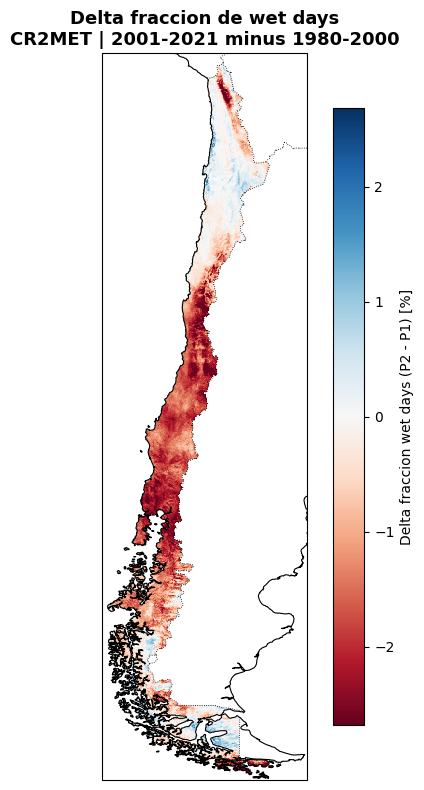

  Fraccion de wet days: escala simetrica +/- 2.687 %


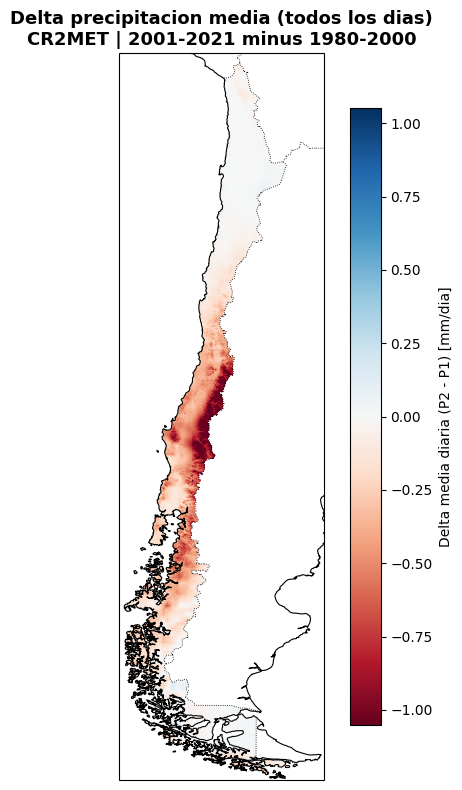

  Media sobre todos los dias: escala simetrica +/- 1.053 mm/dia


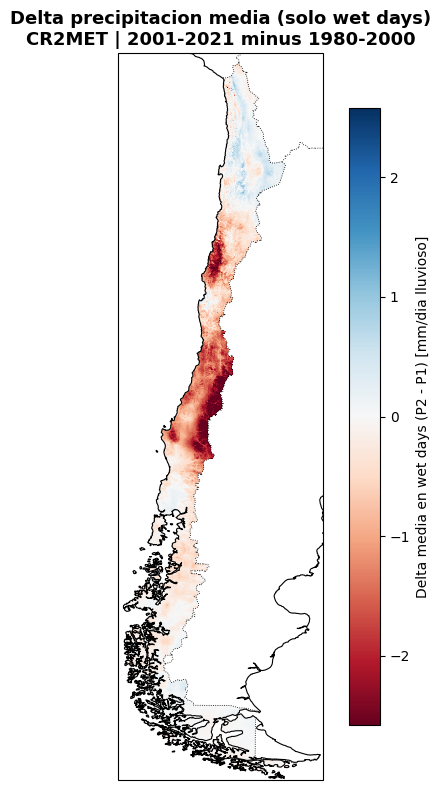

  Media solo en wet days: escala simetrica +/- 2.582 mm/dia lluvioso
Lectura: rojo = disminucion en 2001-2021 vs 1980-2000; azul = aumento.


In [6]:
# =====================================================================
# MAPAS DE DELTA (P2 - P1)
# =====================================================================
print('3/3: Graficando mapas de delta...')

period_label = f'{PERIOD_2[0][:4]}-{PERIOD_2[1][:4]} minus {PERIOD_1[0][:4]}-{PERIOD_1[1][:4]}'

for key, spec in METRIC_SPECS.items():
    vmax = plot_delta_map(
        deltas[key],
        chile_mask,
        title=f"{spec['title']}\nCR2MET | {period_label}",
        cbar_label=spec['cbar'],
    )
    print(f"  {spec['label']}: escala simetrica +/- {vmax:.4g} {spec['units']}")

print('Lectura: rojo = disminucion en 2001-2021 vs 1980-2000; azul = aumento.')